# **FraudShield: Penerapan Algoritma XGBoost dalam Deteksi Transaksi Bank Mencurigakan Berdasarkan Perilaku Nasabah**

## 1. Import Library

In [23]:
# Library Dataset
import kagglehub
import os

# Library Olah & Manipulasi Data
import pandas as pd
import numpy as np

# Library Visualisasi Data (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur Tampilan
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Hide Warning
import warnings
warnings.filterwarnings('ignore')

print(" Semua library berhasil di-import :D")

 Semua library berhasil di-import :D


## 2. Import dan Check Dataset

In [24]:
# Download dataset
path = kagglehub.dataset_download("jatinkhandelwal112/indian-financial-fraud-dataset")
print("Path folder dataset:", path)

# Cek daftar file yang ada di dalam folder
files = os.listdir(path)
print("Daftar file CSV:", files)

# Load file CSV ke dalam DataFrame Pandas
df_customer = pd.read_csv(os.path.join(path, "Cusmtomer_data.csv"))
df_cards = pd.read_csv(os.path.join(path, "Cards_Data.csv"))
df_transactions = pd.read_csv(os.path.join(path, "Transaction_Data_250k.csv"))
df_merchant = pd.read_csv(os.path.join(path, "merchant_table.csv"))

# Output
print("\nSemua database berhasil di-import")

print(f"\nData Customer: {df_customer.shape[0]} baris, {df_customer.shape[1]} kolom")
print("Kolom Customer:", df_customer.columns.tolist())

print(f"\nData Cards: {df_cards.shape[0]} baris, {df_cards.shape[1]} kolom")
print("Kolom Cards:", df_cards.columns.tolist())

print(f"\nData Transactions: {df_transactions.shape[0]} baris, {df_transactions.shape[1]} kolom")
print("Kolom Transactions:", df_transactions.columns.tolist())

print(f"\nData Merchant: {df_merchant.shape[0]} baris, {df_merchant.shape[1]} kolom")
print("Kolom Merchant:", df_merchant.columns.tolist())

Using Colab cache for faster access to the 'indian-financial-fraud-dataset' dataset.
Path folder dataset: /kaggle/input/indian-financial-fraud-dataset
Daftar file CSV: ['Transaction_Data_250k.csv', 'Cusmtomer_data.csv', 'Cards_Data.csv', 'merchant_table.csv']

Semua database berhasil di-import

Data Customer: 25000 baris, 12 kolom
Kolom Customer: ['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Marital_Status', 'Occupation', 'Annual_Income', 'Customer_Segment', 'State', 'City', 'Account_Type', 'Customer_Since']

Data Cards: 32457 baris, 10 kolom
Kolom Cards: ['Card_ID', 'Customer_ID', 'Card_Type', 'Card_Network', 'Credit_Limit', 'Card_Status', 'Contactless', 'Card_Mode', 'Issue_Date', 'Expiry_Date']

Data Transactions: 250000 baris, 20 kolom
Kolom Transactions: ['Transaction_ID', 'Customer_ID', 'Card_ID', 'Merchant_ID', 'Transaction_Date', 'Transaction_Time', 'Transaction_Amount', 'Payment_Method', 'Transaction_Channel', 'Device_Type', 'Transaction_Status', 'Is_International', 'Fraud

## Merged Table CSV

In [25]:
# Merge Transactions + Cards
df_merged = df_transactions.merge(
    df_cards[['Card_ID', 'Card_Type', 'Card_Network', 'Credit_Limit', 'Card_Status', 'Contactless', 'Card_Mode']],
    on='Card_ID',
    how='left'
)

# Merge + Customer
df_merged = df_merged.merge(
    df_customer[['Customer_ID', 'Gender', 'Age', 'Marital_Status', 'Occupation', 'Annual_Income', 'Customer_Segment', 'Account_Type', 'Customer_Since']],
    on='Customer_ID',
    how='left'
)

# Merge + Merchant
df_merged = df_merged.merge(
    df_merchant[['Merchant_ID', 'Merchant_Rating', 'Merchant_Status', 'Merchant_Since']],
    on='Merchant_ID',
    how='left'
)

print(f"Berhasil merge 4 tabel, Total: {df_merged.shape[0]} baris & {df_merged.shape[1]} kolom.")

Berhasil merge 4 tabel, Total: 250000 baris & 37 kolom.


## 3. Data Exploration Analysis (EDA)

### A. Eksplorasi Cek Kesehatan Data

In [26]:
print("INFO DATASET: ")
print(df_merged.info(verbose=False))

print("\nMISSING VALUES: ")
missing = df_merged.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Bersih! Tidak ada missing values.")

print("\nCEK DATA DUPLIKAT: ")
print(f"Jumlah baris duplikat: {df_merged.duplicated().sum()}")

print("\nRASIO TARGET (FRAUD VS NORMAL): ")
print(df_merged['Fraud_Flag'].value_counts(normalize=True) * 100)

INFO DATASET: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Columns: 37 entries, Transaction_ID to Merchant_Since
dtypes: float64(2), int64(5), object(30)
memory usage: 70.6+ MB
None

MISSING VALUES: 
Fraud_Reason    236527
dtype: int64

CEK DATA DUPLIKAT: 
Jumlah baris duplikat: 0

RASIO TARGET (FRAUD VS NORMAL): 
Fraud_Flag
0    94.6108
1     5.3892
Name: proportion, dtype: float64


### B. Eksplorasi Analisis Variabel Numerik

STATISTIK DESKRIPTIF (NORMAL vs FRAUD)


Fraud_Flag                          0           1
Transaction_Amount mean      13104.97    78097.01
                   median     3000.00    11566.29
                   std       20513.89   203897.18
Credit_Limit       mean     443159.01   450312.20
                   median   296288.00   299729.00
                   std      368424.25   372625.57
Annual_Income      mean    1608066.51  1613739.11
                   median   962646.00   972179.00
                   std     1732787.33  1720679.73
Age                mean         41.82       42.01
                   median       41.00       41.00
                   std          13.08       12.95

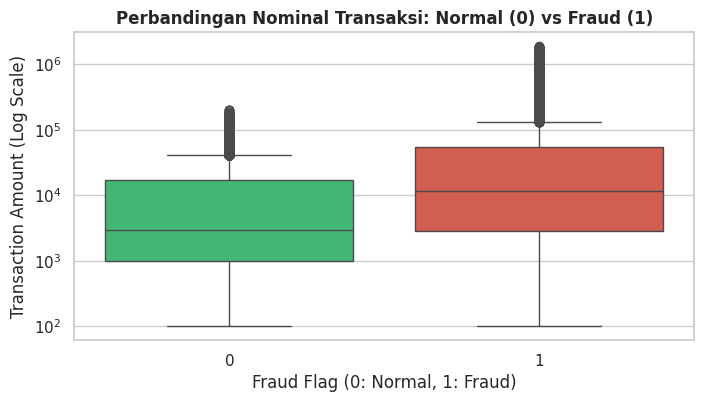

In [27]:
# Ringkasan Statistik Angka Kunci Berdasarkan Fraud_Flag
num_cols = ['Transaction_Amount', 'Credit_Limit', 'Annual_Income', 'Age']
print("STATISTIK DESKRIPTIF (NORMAL vs FRAUD)")
display(df_merged.groupby('Fraud_Flag')[num_cols].agg(['mean', 'median', 'std']).round(2).T)

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_merged, x='Fraud_Flag', y='Transaction_Amount', palette=['#2ecc71', '#e74c3c'])
plt.title('Perbandingan Nominal Transaksi: Normal (0) vs Fraud (1)', fontsize=12, fontweight='bold')
plt.xlabel('Fraud Flag (0: Normal, 1: Fraud)')
plt.ylabel('Transaction Amount (Log Scale)')
plt.yscale('log')
plt.show()

### C. Eksplorasi Analisis Variabel Kategorikal & Risiko Merchant

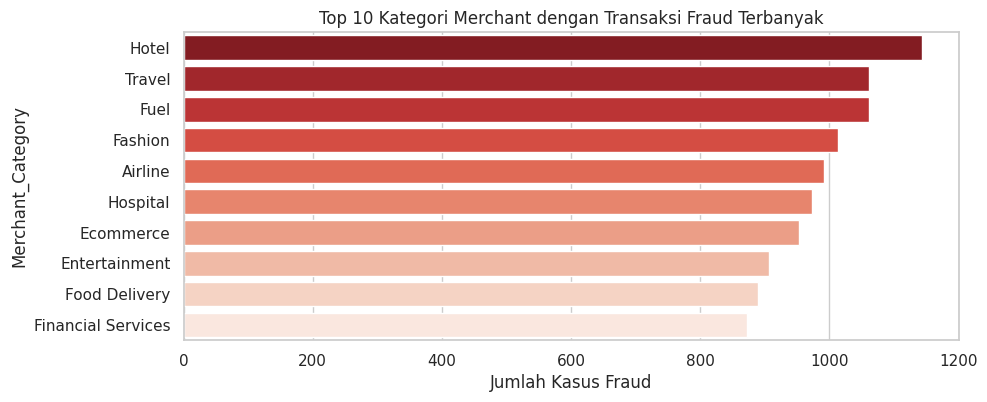

In [28]:
# Kategori Merchant mana yang paling sering kena Fraud
plt.figure(figsize=(10, 4))
sns.countplot(data=df_merged[df_merged['Fraud_Flag'] == 1],
              y='Merchant_Category',
              order=df_merged[df_merged['Fraud_Flag'] == 1]['Merchant_Category'].value_counts().index[:10],
              palette='Reds_r')
plt.title('Top 10 Kategori Merchant dengan Transaksi Fraud Terbanyak')
plt.xlabel('Jumlah Kasus Fraud')
plt.show()

### D. Eksplorasi Analisis Perbandingan Pola Waktu Transaksi

In [29]:
# Perbandingan Transaksi Internasional vs Fraud
pd.crosstab(df_merged['Is_International'], df_merged['Fraud_Flag'], normalize='index') * 100

Fraud_Flag,0,1
Is_International,,
0,95.368280,4.631720
1,80.305441,19.694559


## 4. Data Preprocessing & Feature Engineering

### A. Feature Engineering (Menambah Kolom)

In [30]:
# Buat copy dari dataset gabungan
df_feat = df_merged.copy()

print("Sedang memproses Feature Engineering...")

# Feature Engineering berdasarkan Lokasi (Mismatch Detection)
# Cek apakah provinsi nasabah beda dengan provinsi merchant
df_feat['Is_State_Mismatch'] = (df_feat['Customer_State'] != df_feat['Merchant_State']).astype(int)
df_feat['Is_City_Mismatch'] = (df_feat['Customer_City'] != df_feat['Merchant_City']).astype(int)

# Feature Engineering Rasio Finansial
# Rasio nominal transaksi terhadap limit kartu
df_feat['Amount_to_Limit_Ratio'] = df_feat['Transaction_Amount'] / (df_feat['Credit_Limit'] + 1)

# Rasio nominal transaksi terhadap pendapatan tahunan
df_feat['Amount_to_Income_Ratio'] = df_feat['Transaction_Amount'] / (df_feat['Annual_Income'] + 1)

# Pengolahan Waktu (Date & Time Features)
# Ekstrak Jam dari Transaction_Time (misal "14:30:00" -> 14)
df_feat['Transaction_Hour'] = pd.to_datetime(df_feat['Transaction_Time'], format='%H:%M:%S', errors='coerce').dt.hour

# Ekstrak Hari, Bulan, dan Weekend dari Transaction_Date
df_feat['Transaction_Date'] = pd.to_datetime(df_feat['Transaction_Date'], errors='coerce')
df_feat['Transaction_DayOfWeek'] = df_feat['Transaction_Date'].dt.dayofweek
df_feat['Is_Weekend'] = df_feat['Transaction_DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# Cek transaksi jam malam (22:00 - 05:00) yang biasanya lebih rawan fraud
df_feat['Is_Night_Transaction'] = df_feat['Transaction_Hour'].apply(lambda x: 1 if (x >= 22 or x <= 5) else 0)

# 4. Hapus Kolom ID & Leakage Variables (Kolom penjelas setelah kejadian)
# Kolom Fraud_Reason, ID, Nama, dan Tanggal mentah harus di-drop agar model tidak 'cheating'
cols_to_drop = [
    'Transaction_ID', 'Customer_ID', 'Card_ID', 'Merchant_ID',
    'Customer_Name', 'Fraud_Reason',
    'Transaction_Date', 'Transaction_Time', 'Issue_Date', 'Expiry_Date', 'Customer_Since', 'Merchant_Since'
]

# Drop kolom jika ada di dataframe
df_feat = df_feat.drop(columns=[col for col in cols_to_drop if col in df_feat.columns])

print("Fitur baru berhasil dibuat & kolom leakage dibersihkan!")
print(f"Bentuk data saat ini: {df_feat.shape[0]} baris & {df_feat.shape[1]} kolom.")

Sedang memproses Feature Engineering...
Fitur baru berhasil dibuat & kolom leakage dibersihkan!
Bentuk data saat ini: 250000 baris & 36 kolom.


### b. Encoding Data

In [31]:
from sklearn.preprocessing import LabelEncoder

# Salin dataframe untuk encoding
df_encoded = df_feat.copy()

# Cari semua kolom bertipe objek (teks/kategori)
cat_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()

print(f"Kolom kategorikal yang akan di-encode ({len(cat_cols)} kolom):")
print(cat_cols)

# Lakukan Label Encoding untuk setiap kolom teks
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Ubah ke string dulu untuk mengantisipasi adanya tipe campuran
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le  # Simpan encoder jika nanti butuh dipanggil di Streamlit

print("\nSelesai! Semua variabel kategorikal berhasil diubah jadi angka.")
df_encoded.head()

Kolom kategorikal yang akan di-encode (21 kolom):
['Payment_Method', 'Transaction_Channel', 'Device_Type', 'Transaction_Status', 'Merchant_Risk_Level', 'Merchant_Category', 'Customer_State', 'Customer_City', 'Merchant_State', 'Merchant_City', 'Card_Type', 'Card_Network', 'Card_Status', 'Contactless', 'Card_Mode', 'Gender', 'Marital_Status', 'Occupation', 'Customer_Segment', 'Account_Type', 'Merchant_Status']

Selesai! Semua variabel kategorikal berhasil diubah jadi angka.


,Transaction_Amount,Payment_Method,Transaction_Channel,Device_Type,Transaction_Status,Is_International,Fraud_Flag,Merchant_Risk_Level,Merchant_Category,Customer_State,...,Merchant_Rating,Merchant_Status,Is_State_Mismatch,Is_City_Mismatch,Amount_to_Limit_Ratio,Amount_to_Income_Ratio,Transaction_Hour,Transaction_DayOfWeek,Is_Weekend,Is_Night_Transaction
0,21748.02,1,1,1,2,1,0,1,11,11,...,4.3,0,0,1,0.137208,0.028844,5,6,1,1
1,9960.60,1,3,3,2,0,0,1,13,5,...,4.1,0,1,1,0.025427,0.002571,6,2,0,0
2,838.61,1,0,0,2,0,0,1,7,13,...,4.0,0,1,1,0.000604,0.000262,2,2,0,1
3,52694.99,0,3,3,2,0,0,1,6,9,...,4.4,0,1,1,0.037326,0.017683,1,3,0,1
4,1043.40,1,2,1,2,0,0,1,4,7,...,4.9,0,1,1,0.003905,0.002745,0,6,1,1


## 5. Model Training & Evaluation (XGBoost)

### A. Split Data

In [32]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

# Memisahkan Feature (X) dan Target (y)
X = df_encoded.drop(columns=['Fraud_Flag'])
y = df_encoded['Fraud_Flag']

# Train-Test Split (80% Train, 20% Test)
# Gunakan stratify=y agar proporsi Fraud_Flag tetap sama di data train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Training : {X_train.shape[0]} baris")
print(f"Data Testing  : {X_test.shape[0]} baris")

# Menghitung bobot penyeimbang (scale_pos_weight)
# Formula: (Jumlah Data Normal) / (Jumlah Data Fraud)
num_negative = (y_train == 0).sum()
num_positive = (y_train == 1).sum()
scale_pos_weight_value = num_negative / num_positive

print(f"\nNilai scale_pos_weight untuk XGBoost: {scale_pos_weight_value:.2f}")

Data Training : 200000 baris
Data Testing  : 50000 baris

Nilai scale_pos_weight untuk XGBoost: 17.56


### B. Training Model & Evaluasi XGBoost

Sedang melatih model XGBoost...
Training selesai!

✨CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Normal (0)       1.00      0.95      0.97     47305
   Fraud (1)       0.51      0.92      0.66      2695

    accuracy                           0.95     50000
   macro avg       0.75      0.94      0.82     50000
weighted avg       0.97      0.95      0.96     50000

ROC-AUC Score: 0.9828


<Figure size 600x500 with 0 Axes>

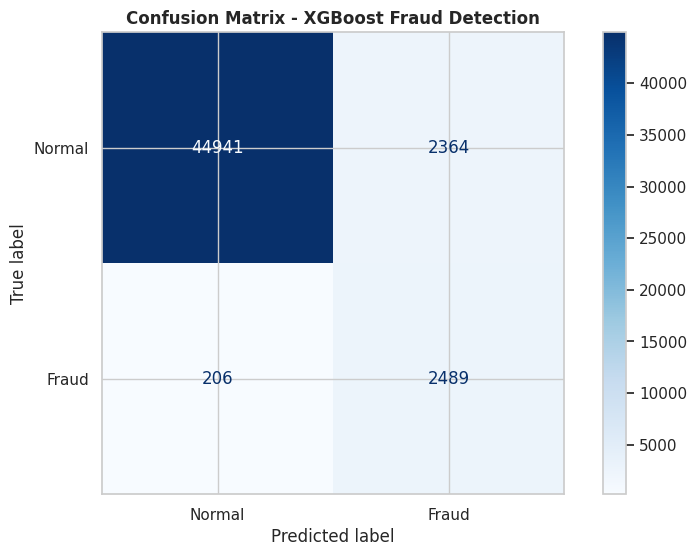

In [34]:
# Inisialisasi Model XGBoost
model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    n_jobs=-1
)

print("Sedang melatih model XGBoost...")
model_xgb.fit(X_train, y_train)
print("Training selesai!")

# Prediksi pada Data Test
y_pred = model_xgb.predict(X_test)
y_pred_proba = model_xgb.predict_proba(X_test)[:, 1]

# Cetak Laporan Evaluasi
print("\n" + "="*50)
print("✨CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Fraud (1)']))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - XGBoost Fraud Detection', fontweight='bold')
plt.show()

## 6. Save Model

In [37]:
import joblib
from google.colab import files

model_data = {
    'model': model_xgb,
    'features': X.columns.tolist(),
    'label_encoders': label_encoders
}

joblib.dump(model_data, "xgboost_fraud_model.pkl")
files.download("xgboost_fraud_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Save Dataset

In [36]:
from google.colab import files
df_feat.to_csv("cleaned_fraud_data.csv", index=False)
print("File 'cleaned_fraud_data.csv' berhasil dibuat")
files.download("cleaned_fraud_data.csv")

File 'cleaned_fraud_data.csv' berhasil dibuat


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>